<a href="https://colab.research.google.com/github/amrutha2413/ASLDetection/blob/main/ASLDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Found 1865 files belonging to 6 classes.
Using 1492 files for training.
Found 1865 files belonging to 6 classes.
Using 373 files for validation.
Classes: ['A', 'B', 'C', 'D', 'E', 'sample_data']


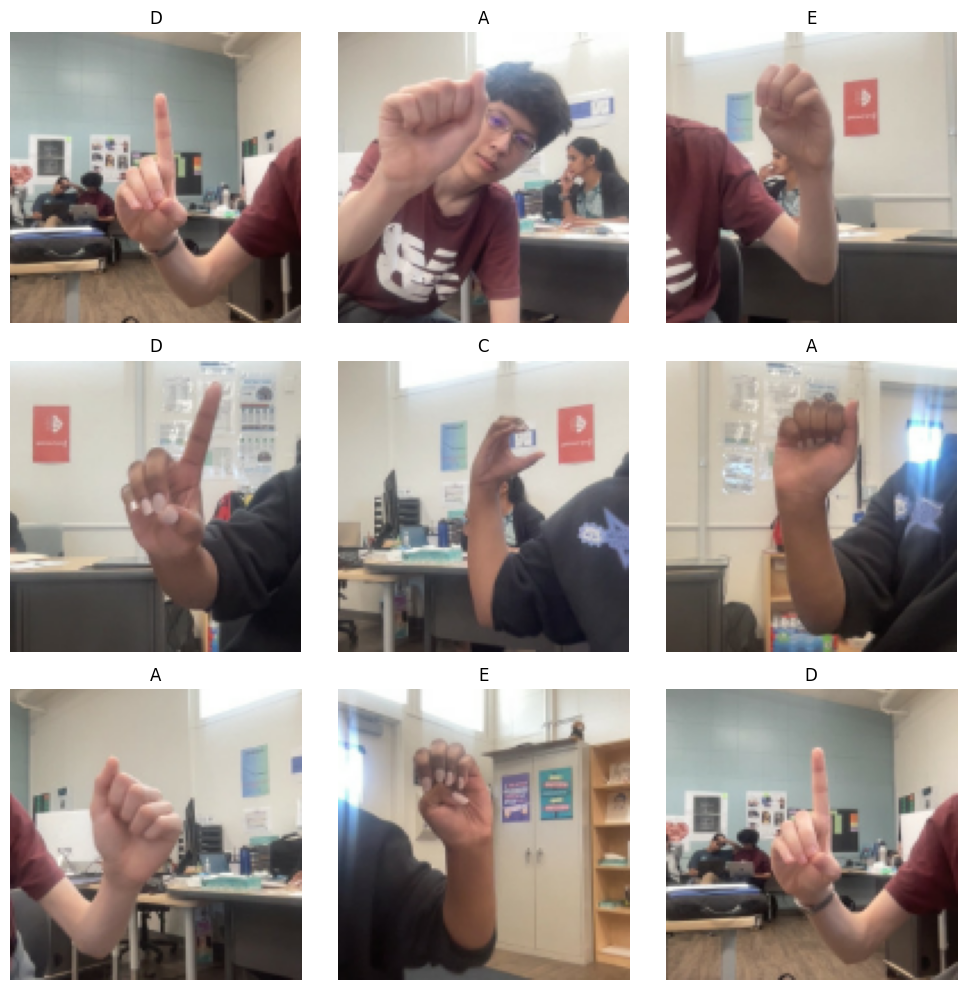

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,414 (12.61 MB)

 Trainable params: 3,305,414 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.2761 - loss: 1.6186 - val_accuracy: 0.6273 - val_loss: 1.4095
Epoch 2/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.5067 - loss: 1.2088 - val_accuracy: 0.7292 - val_loss: 0.8001
Epoch 3/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.7286 - loss: 0.7224 - val_accuracy: 0.7694 - val_loss: 0.5386
Epoch 4/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.8271 - loss: 0.4863 - val_accuracy: 0.9732 - val_loss: 0.1175
Epoch 5/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.9223 - loss: 0.2244 - val_accuracy: 0.9383 - val_loss: 0.1418
Epoch 6/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.9310 - loss: 0.2005 - val_accuracy: 0.9786 - val_loss: 0.0665
Epoch 7/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.9571 - loss: 0.1392 - val_accuracy: 0.9866 - val_loss: 0.0274
Epoch 8/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.9705 - loss: 0.0838 - val_accuracy: 0.9920 - val_loss:

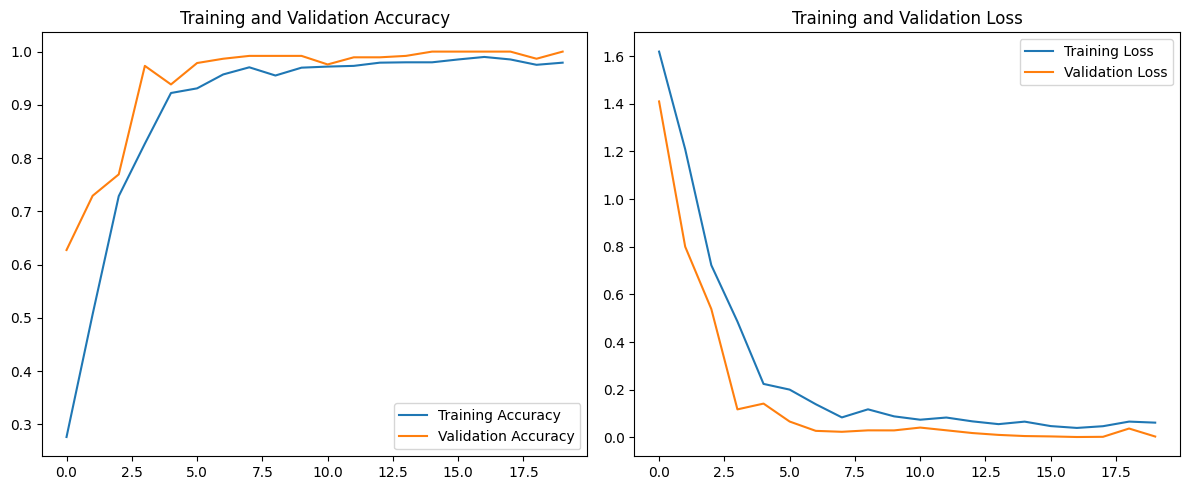

Macro F1 Score: 1.0000
Weighted F1 Score: 1.0000

Classification Report:


ValueError: Number of classes, 5, does not match size of target_names, 6. Try specifying the labels parameter

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import seaborn as sns

dataset_path = "/content"

img_height = 128
img_width = 128
batch_size = 32
seed = 123

#Upload Dataset
train_ds = image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
print("Classes:", class_names)

#Data Pipline
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)


#SHOW SAMPLE IMAGES

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.tight_layout()
plt.show()


data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

#Build CNN Model
num_classes = len(class_names)
model = models.Sequential([
    layers.Input(shape=(img_height, img_width, 3)),

    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax') # Changed from 5 to num_classes
])

model.summary()

#Complete Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#Training
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop]
)



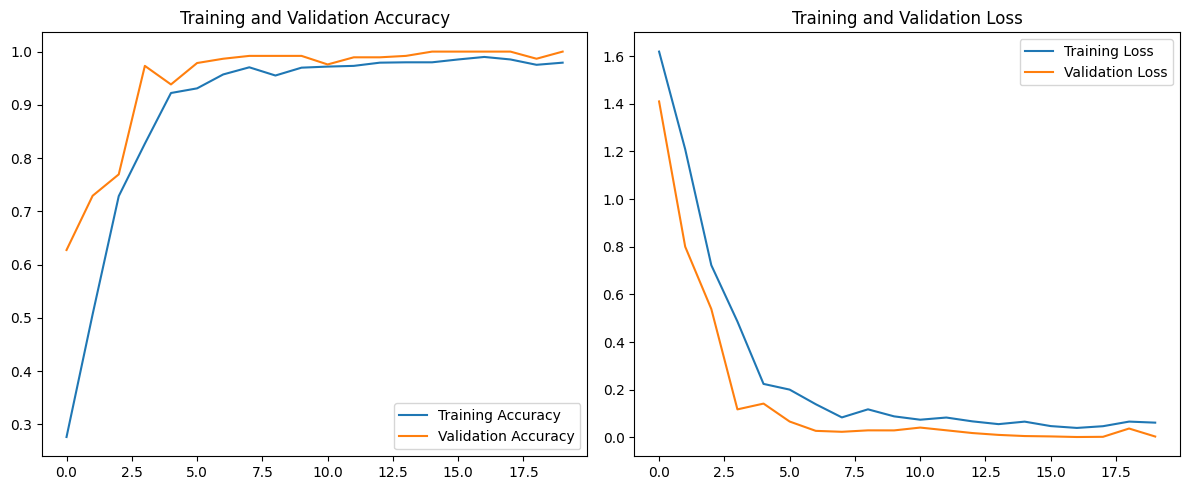

Macro F1 Score: 1.0000
Weighted F1 Score: 1.0000

Classification Report:
              precision    recall  f1-score   support

           A       1.00      1.00      1.00        69
           B       1.00      1.00      1.00        77
           C       1.00      1.00      1.00        76
           D       1.00      1.00      1.00        81
           E       1.00      1.00      1.00        70

    accuracy                           1.00       373
   macro avg       1.00      1.00      1.00       373
weighted avg       1.00      1.00      1.00       373



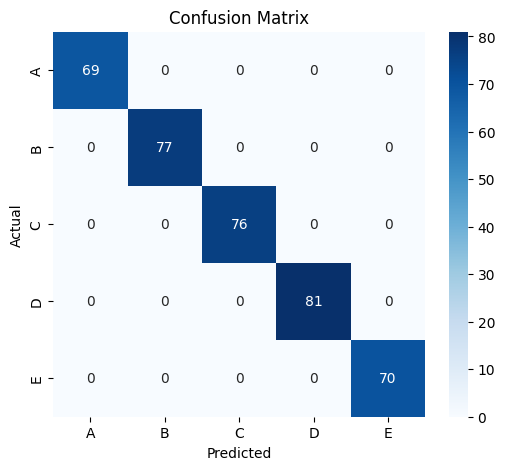

In [ ]:
#plots
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Training and Validation Loss')

plt.tight_layout()
plt.show()

#predictions
y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)


#Final Report
macro_f1 = f1_score(y_true, y_pred, average='macro')
weighted_f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Macro F1 Score: {macro_f1:.4f}")
print(f"Weighted F1 Score: {weighted_f1:.4f}")

print("\nClassification Report:")
# Filter class_names to exclude 'sample_data' as it's not part of the actual labels (0-4)
filtered_class_names = [name for name in class_names if name != 'sample_data']
print(classification_report(y_true, y_pred, target_names=filtered_class_names))

#Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=filtered_class_names, yticklabels=filtered_class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Model saved as asl_letters_A_E_model.h5
